# Deep Learning for Computer Vision

## Project 2 - Use of Data Augmentation and Transfer Learning

**Authors:** António Cruz (140129), David Isaac (120064), Erik Daskalyuk (120062), Ivan Magalhães (106586), Ricardo Pereira (120052)

**Date:** 2025-11-30

# 1. Business Understanding

---

## Scope

This project focuses on developing an AI-powered classification model using transfer learning to analyze chest X-ray images and identify patients with pneumonia. Building on the foundational work of Project 1, this project explores advanced deep learning techniques to improve model performance, generalization, and clinical utility.

The project leverages pre-trained convolutional neural networks (CNNs)—such as VGG16, ResNet50, and EfficientNet—to extract meaningful features from chest X-ray images. By fine-tuning these models and applying data augmentation, the goal is to enhance the model's ability to generalize to unseen data while maintaining a strong focus on high recall, ensuring that pneumonia cases are not missed.

The system will:
- Classify chest X-ray images into Normal and Pneumonia categories.
- Enable healthcare professionals to retrospectively identify at-risk patients for targeted preventive care, reducing the risk of pneumonia recurrence and complications.

## Objectives

1. Implement Transfer Learning
   Develop a classification model using pre-trained CNNs (e.g., VGG16, ResNet50, EfficientNet) as a baseline, leveraging their ability to extract high-level features from medical images.

2. Experiment with Data Augmentation
   Apply transformations such as rotation, zoom, and flipping to artificially expand the training dataset, improving model robustness and reducing overfitting.

3. Explore Feature Extraction and Fine-Tuning
   - Feature Extraction: Use pre-trained models as fixed feature extractors, training only the top classifier layers.
   - Fine-Tuning: Unfreeze and retrain later layers of the pre-trained models to adapt them specifically to the chest X-ray classification task.

4. Evaluate Model Performance
   Compare the performance of different architectures and techniques using clinically relevant metrics, including accuracy, precision, recall, F1-score, and AUC-ROC, with an emphasis on recall to ensure that pneumonia cases are not overlooked.

5. Justify the Best-Performing Model
   Provide a detailed analysis of why the selected model (e.g., ResNet50 with fine-tuning) outperforms others, considering trade-offs such as training time, computational resources, and clinical utility.

6. Deliver a Functional and Documented Solution
   Provide a well-documented Python codebase and a comprehensive report detailing the dataset, methodology, model architecture, training process, evaluation results, and the rationale behind the selected model and techniques.

## Clinical and Operational Impact

The project aims to deliver a practical, recall-focused AI model that assists healthcare professionals in identifying patients with a history of pneumonia from historical X-ray records. By enabling targeted preventive interventions, the model supports secondary prevention efforts, reducing the risk of recurrence and improving patient outcomes.

# 2. Data Understanding
---

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import cv2
from scipy.stats import entropy, kurtosis, skew
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
from sklearn.utils import class_weight as sk_class_weight

import tensorflow as tf
from keras import Input, models, layers, regularizers
from keras.callbacks import ModelCheckpoint
from keras.utils import image_dataset_from_directory
from keras.callbacks import ReduceLROnPlateau
from keras.callbacks import EarlyStopping
from keras.optimizers import AdamW
from keras.metrics import AUC, Precision, Recall

2025-11-25 00:55:02.010431: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-25 00:55:02.047512: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-25 00:55:03.130299: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
# Global configuration
SEED = 42                                        # Fixed random seed for reproducibility
BATCH_SIZE = 32                                  # Number of images per training batch
LEARNING_RATE = 1e-4                             # Initial learning rate for the optimizer
DATASET_ROOT = "./chest_xray/"                   # Set the dataset location base path
CHECKPOINT_PATH = "best_model_checkpoint.keras"  # File path to save the best model
ACTIVE_SCENARIO = "DEVELOPMENT"                  # Active scenario selected: "DEVELOPMENT", "STAGING", "PRODUCTION"

In [3]:
# Set random seeds for reproducibility across libraries
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
# Set paths for train and test datasets
train_dir = DATASET_ROOT + "train"
test_dir = DATASET_ROOT + "test"

In [ ]:
# Helper function to check the active scenario
def scenario(*modes):
    # If in PRODUCTION, everything is allowed
    if ACTIVE_SCENARIO == "PRODUCTION":
        return True
    # Otherwise only allow explicitly listed modes
    return ACTIVE_SCENARIO in modes

# Utility: parse dataset folders into a DataFrame
def load_dataset_df(train_root, test_root):
    """Build a DataFrame with columns: image_path, label, split."""
    records = []

    # Parse training split folders
    for label_name in os.listdir(train_root):
        label_dir = os.path.join(train_root, label_name)
        if not os.path.isdir(label_dir):
            continue

        for f in os.listdir(label_dir):
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                records.append({
                    "image_path": os.path.join(label_dir, f),
                    "label": label_name,
                    "split": "train"
                })

    # Parse test split folders
    for label_name in os.listdir(test_root):
        label_dir = os.path.join(test_root, label_name)
        if not os.path.isdir(label_dir):
            continue

        for f in os.listdir(label_dir):
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                records.append({
                    "image_path": os.path.join(label_dir, f),
                    "label": label_name,
                    "split": "test"
                })

    return pd.DataFrame(records)

In [6]:
# Create DF_ORIGIN, the immutable reference DataFrame
DF_ORIGIN = load_dataset_df(train_dir, test_dir)

print("DF_ORIGIN created:")
display(DF_ORIGIN.head())
print(f"Total images: {len(DF_ORIGIN)}")

# DF_VIEW, it will be used for Business and Data Understanding
DF_VIEW  = DF_ORIGIN.copy()

# DF_TRAIN, it will be used for Data Preparation and Modeling
DF_TRAIN = DF_ORIGIN.copy()

print("\nDataset copies created:")
print(f"df_view : {len(DF_VIEW)} rows")
print(f"df_train: {len(DF_TRAIN)} rows")

DF_ORIGIN created:


,image_path,label,split
0,./chest_xray/train/NORMAL/NORMAL2-IM-0911-0001...,NORMAL,train
1,./chest_xray/train/NORMAL/IM-0477-0001.jpeg,NORMAL,train
2,./chest_xray/train/NORMAL/NORMAL2-IM-0974-0001...,NORMAL,train
3,./chest_xray/train/NORMAL/IM-0548-0001.jpeg,NORMAL,train
4,./chest_xray/train/NORMAL/NORMAL2-IM-0917-0001...,NORMAL,train


Total images: 5856

Dataset copies created:
df_view : 5856 rows
df_train: 5856 rows


In [ ]:
# Global Contrast (std)
def compute_global_std(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.nan
    return float(np.std(img.astype(np.float32)))

# Dynamic Range (max - min)
def compute_dynamic_range(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.nan
    img = img.astype(np.float32)
    return float(np.max(img) - np.min(img))

# Histogram Entropy
def compute_hist_entropy(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.nan
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    p = hist.ravel().astype(np.float32)
    p = p / np.sum(p)
    p[p == 0] = 1e-12
    return float(entropy(p, base=2))

# Kurtosis and Skewness
def compute_kurtosis_skew(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.nan, np.nan
    vals = img.astype(np.float32).ravel()
    return float(kurtosis(vals)), float(skew(vals))

# Local Contrast Uniformity (tile std mean & variance)
def compute_local_contrast(path, tiles=8):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.nan, np.nan

    img = img.astype(np.float32)
    h, w = img.shape
    tile_h = h // tiles
    tile_w = w // tiles

    stds = []
    for i in range(tiles):
        for j in range(tiles):
            tile = img[i * tile_h:(i + 1) * tile_h,
                       j * tile_w:(j + 1) * tile_w]
            stds.append(np.std(tile))

    stds = np.array(stds)
    return float(stds.mean()), float(stds.var())

# High-Frequency Content (mean Laplacian)
def compute_high_freq_energy(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.nan
    lap = cv2.Laplacian(img.astype(np.float32), cv2.CV_32F)
    return float(np.mean(np.abs(lap)))

## 2.1 Global Contrast

A stable model performance requires a dataset with relatively consistent exposure and contrast characteristics. Large fluctuations in global contrast, whether caused by acquisition variability, compression artifacts, or post-processing, can lead to heterogeneous feature distributions during training. Such variability increases the risk of the model focusing on contrast artifacts rather than clinically relevant patterns. Quantifying global contrast supports the identification of low-quality or overprocessed images that may require correction, filtering, or consistent preprocessing prior to model training.

Global contrast, expressed as the standard deviation of pixel intensities, is a fundamental indicator of image quality in chest radiography. Diagnostic information in X-ray images depends heavily on subtle grayscale variations that delineate lung fields, soft-tissue boundaries, vascular structures, and osseous anatomy. Low global contrast typically indicates underexposure or suboptimal acquisition, which can obscure anatomical details and reduce the discriminative capacity available to a learning algorithm. Conversely, excessively high global contrast often suggests overprocessing or artificial enhancement, potentially introducing edges and textures not present in standard clinical imaging.

As part of dataset characterization, this metric establishes a baseline reference for expected exposure and contrast levels across the available images. This baseline assists in determining whether contrast normalization methods (e.g., histogram normalization, CLAHE, or no enhancement) are necessary or potentially counterproductive. It also provides a reference against which future inference-time images can be compared, helping to detect contrast outliers that may result from differing acquisition settings, device variability, or prior preprocessing.

In [15]:
# Compute Global Contrast (standard deviation of pixel intensities)
if scenario("DEVELOPMENT"):

    DF_VIEW["global_std"] = DF_VIEW["image_path"].apply(compute_global_std)

    print("Global contrast computation completed.")
    display(DF_VIEW["global_std"].describe())

Global contrast computation completed.


count    5856.000000
mean       56.989903
std         9.396742
min        20.415352
25%        50.736894
50%        57.328350
75%        63.696505
max        87.480423
Name: global_std, dtype: float64

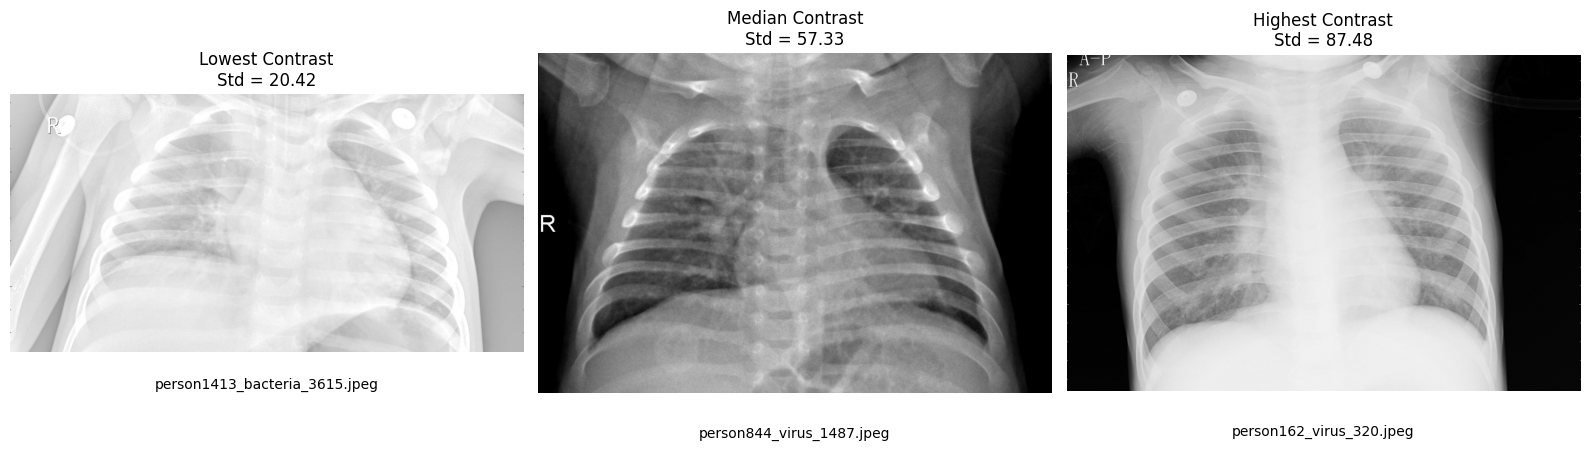

In [14]:
# Plot Lowest, Median and Highest Contrast Images
if scenario("DEVELOPMENT"):

    # Sort DF_VIEW by global contrast
    df_sorted = DF_VIEW.sort_values(by="global_std")

    # Select lowest, median, highest contrast samples
    low_row  = df_sorted.iloc[0]
    mid_row  = df_sorted.iloc[len(df_sorted) // 2]
    high_row = df_sorted.iloc[-1]

    selected = [
        ("Lowest Contrast",  low_row["image_path"],  low_row["global_std"]),
        ("Median Contrast",  mid_row["image_path"],  mid_row["global_std"]),
        ("Highest Contrast", high_row["image_path"], high_row["global_std"])
    ]

    plt.figure(figsize=(16, 7))

    for idx, (label, path, std_val) in enumerate(selected):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Image could not be read: {path}")

        filename = os.path.basename(path)

        plt.subplot(1, 3, idx + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"{label}\nStd = {std_val:.2f}", fontsize=12)
        plt.axis("off")

        plt.text(
            0.5, -0.10,
            filename,
            fontsize=10,
            ha="center", va="top",
            transform=plt.gca().transAxes
        )

    plt.tight_layout()
    plt.show()

**Figure 2.1** - Lowest, Median and Highest Contrast Images

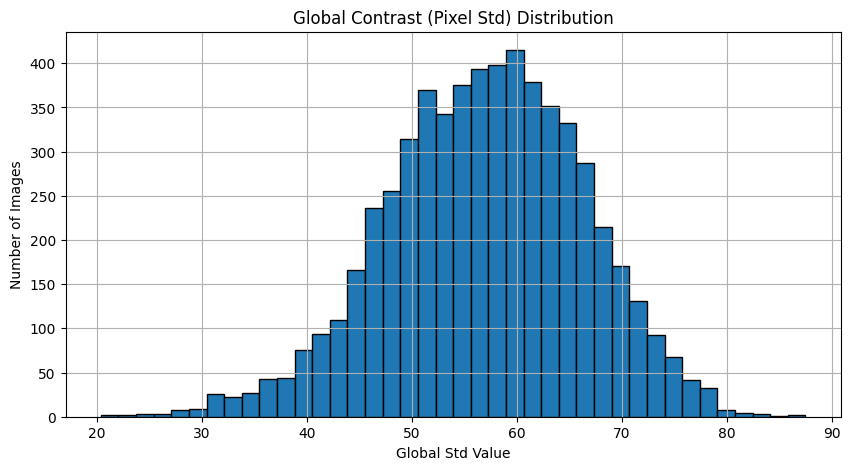

In [16]:
# Plot Global Contrast Distribution
if scenario("DEVELOPMENT"):

    plt.figure(figsize=(10, 5))
    plt.hist(DF_VIEW["global_std"].dropna(), bins=40, edgecolor='black')

    plt.title("Global Contrast (Pixel Std) Distribution")
    plt.xlabel("Global Std Value")
    plt.ylabel("Number of Images")
    plt.grid(True)

    plt.show()

**Figure 2.2** - Global Contrast Distribution

The distribution of global contrast values shows a well-formed, approximately Gaussian shape centered around the expected range for standard chest radiographs. This suggests that the majority of images share similar exposure and contrast characteristics, which is desirable for model training. The presence of a small number of low-contrast images at the left tail likely reflects instances of mild underexposure or limited dynamic range. Likewise, the small number of high-contrast cases at the right tail may correspond to images that have undergone stronger post-processing or contrast amplification.

Overall, the dataset appears broadly consistent in terms of contrast quality. The core of the distribution indicates that most images fall within a stable and clinically plausible contrast band, which supports robust model learning. The few outliers observed at the extremes do not dominate the dataset and may be reviewed individually during preprocessing decisions, but they do not suggest any structural imbalance or heterogeneous mixing of incompatible imaging sources.

## 2.2 Dynamic Range

Dynamic range, defined as the difference between the maximum and minimum pixel intensities in an image, serves as a measure of how fully the grayscale space is utilized during acquisition. Chest X-ray imaging relies on a broad representation of intensities to preserve the visibility of both low-attenuation regions such as lung fields and high-attenuation structures such as ribs or the mediastinum. An image with a limited dynamic range may appear washed out or uniformly gray, which reduces the visibility of diagnostically relevant structures. Conversely, an abnormally wide dynamic range may indicate strong post-processing, unusual acquisition parameters, or inconsistent normalization steps applied before dataset construction.

A dataset with large variability in dynamic range can introduce significant inconsistency in the distribution of pixel intensities seen during training. This inconsistency makes it more difficult for a model to learn reliable patterns, as the same anatomical structure may appear substantially lighter or darker depending on acquisition conditions rather than actual physiology. Monitoring this metric makes it possible to identify images that deviate from standard radiographic appearance and that may require normalization or exclusion. A stable and well-defined dynamic range across samples contributes to more predictable model behavior and reduces the risk of learning contrast artifacts.

Dynamic range analysis complements global contrast analysis by providing a direct measurement of the span of intensities present in each image. Whereas the global standard deviation characterizes the distribution’s spread, dynamic range assesses the actual minimum and maximum gray levels used by the imaging system. Together, these metrics assist in determining whether preprocessing steps such as intensity clipping, histogram normalization, or contrast equalization are necessary to achieve a consistent representation of the dataset. They also support the identification of outliers that may result from non-standard imaging devices or prior enhancement.

In [17]:
# Compute Dynamic Range (max intensity minus min intensity)
if scenario("DEVELOPMENT"):

    # Create the column
    DF_VIEW["dynamic_range"] = DF_VIEW["image_path"].apply(compute_dynamic_range)

    print("Dynamic Range computation completed.")
    display(DF_VIEW["dynamic_range"].describe())

Dynamic Range computation completed.


count    5856.000000
mean      252.547473
std        11.851924
min       122.000000
25%       255.000000
50%       255.000000
75%       255.000000
max       255.000000
Name: dynamic_range, dtype: float64

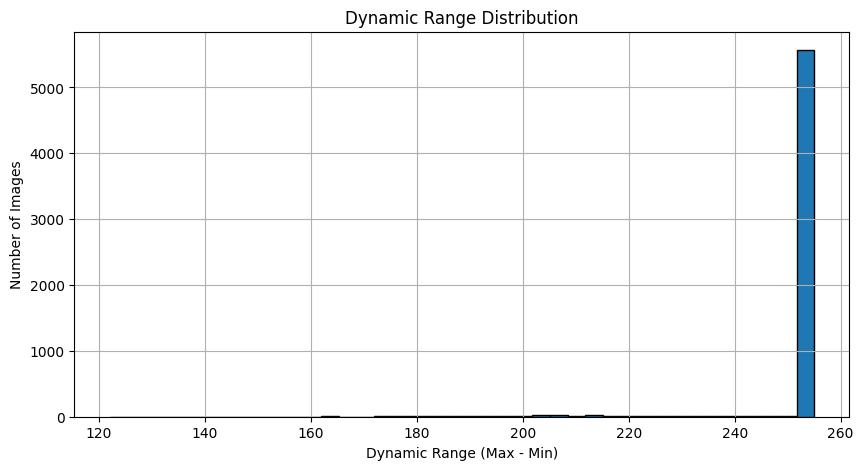

In [18]:
# Plot distribution of Dynamic Range values
if scenario("DEVELOPMENT"):

    plt.figure(figsize=(10, 5))
    plt.hist(DF_VIEW["dynamic_range"].dropna(), bins=40, edgecolor="black")

    plt.title("Dynamic Range Distribution")
    plt.xlabel("Dynamic Range (Max - Min)")
    plt.ylabel("Number of Images")
    plt.grid(True)

    plt.show()

**Figure 2.3** - Dynamic Range Distribution

Overall, the dataset appears highly uniform in terms of dynamic range. The dominant peak at 255 indicates consistent handling of intensity rescaling across images, which is advantageous for downstream modelling, as the input space remains stable. The small tail of lower dynamic-range images can be inspected individually during the data-quality review phase, but the distribution does not suggest any systemic inconsistency in acquisition or preprocessing.

## 2.3 Histogram Entropy

Histogram entropy measures the complexity and variability of the grayscale distribution in an image. Higher entropy values indicate that pixel intensities are more uniformly distributed across the available range, reflecting greater diversity in tonal values. Lower entropy values occur when intensities are concentrated in a narrower subset of values, producing flatter or more uniform images. In the context of chest radiography, entropy provides an aggregate view of how much tonal information the acquisition contains. Images with low entropy may be underexposed, washed out, or lacking structural definition, while images with very high entropy may have undergone strong contrast equalization or other enhancement steps.

Stable entropy levels across a dataset contribute to consistent feature extraction during training. Variations in entropy reflect differences in perceptual complexity, structural prominence, and contrast distribution, all of which influence how convolutional layers respond to radiographic textures. An image with unusually low entropy may lack sufficient local variation for robust learning, while an image with unusually high entropy may contain contrast artifacts that do not represent normal anatomy. By quantifying entropy across the dataset, it becomes possible to detect samples that deviate from the expected radiographic appearance and that may benefit from targeted normalization or exclusion.

Histogram entropy complements the global standard deviation and dynamic range metrics by capturing the distributional shape of image intensities rather than only the spread or the minimum and maximum values. Together, these metrics help characterize the global exposure profile of the dataset and guide decisions regarding preprocessing steps such as histogram normalization or contrast equalization. Entropy also establishes a reference distribution against which future inference-time inputs can be compared, supporting the identification of atypical acquisition conditions or unexpected preprocessing in production data.

In [ ]:
# Sort images by histogram entropy
df_sorted_entropy = df_entropy.sort_values(by="hist_entropy")

# Identify lowest, median, and highest entropy samples
low_e = df_sorted_entropy.iloc[0]
mid_e = df_sorted_entropy.iloc[len(df_sorted_entropy) // 2]
high_e = df_sorted_entropy.iloc[-1]

entropy_examples = [
    ("Lowest Entropy", low_e["image"], low_e["hist_entropy"]),
    ("Median Entropy", mid_e["image"], mid_e["hist_entropy"]),
    ("Highest Entropy", high_e["image"], high_e["hist_entropy"])
]

# Plot representative images with file names shown below
plt.figure(figsize=(16, 7))

for idx, (label, path, e_val) in enumerate(entropy_examples):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    filename = os.path.basename(path)

    plt.subplot(1, 3, idx + 1)
    plt.imshow(img, cmap="gray")

    # Title above the image
    plt.title(f"{label}\nEntropy = {e_val:.2f} bits", fontsize=12)

    plt.axis("off")

    # File name below the image
    plt.text(
        0.5, -0.10, filename,
        fontsize=10,
        ha='center', va='top',
        transform=plt.gca().transAxes
    )

plt.tight_layout()
plt.show()

**Figure 2.4** - Lowest, Median, and Highest Entropy Images

In [ ]:
# Compute histogram entropy for a single image
def compute_hist_entropy(image_path):
	img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
	if img is None:
		return None
	hist = cv2.calcHist([img], [0], None, [256], [0, 256])
	hist = hist.ravel().astype(np.float32)
	p = hist / np.sum(hist)
	p = np.where(p == 0, 1e-12, p)
	return float(entropy(p, base=2))

# Compute histogram entropy for all dataset images
results_entropy = []
for path in all_paths:
	h = compute_hist_entropy(path)
	if h is not None:
		results_entropy.append({"image": path, "hist_entropy": h})

df_entropy = pd.DataFrame(results_entropy)

# Display descriptive statistics
display(df_entropy.describe())

In [ ]:
# Plot the histogram entropy distribution
plt.figure(figsize=(10, 5))
plt.hist(df_entropy["hist_entropy"], bins=40, edgecolor='black')
plt.title("Histogram Entropy Distribution")
plt.xlabel("Entropy (bits)")
plt.ylabel("Number of Images")
plt.grid(True)
plt.show()

**Figure 2.5** - Histogram Entropy Distribution

The entropy distribution shows a well-defined concentration around values between approximately 6.9 and 7.6 bits, indicating that most images exhibit a balanced spread of pixel intensities across the grayscale range. This range reflects an expected level of tonal complexity for chest radiographs in which both low-attenuation and high-attenuation structures are adequately represented. The presence of a smooth, unimodal shape suggests a consistent image formation process across the dataset, with no major groups of images derived from markedly different acquisition or post-processing pipelines.

A smaller number of images appear in the lower-entropy tail, with values between 6.0 and 6.5 bits. These cases may correspond to underexposed or low-contrast scans in which intensity values are compressed into a narrow portion of the grayscale space. Conversely, the images near the upper end of the distribution reach entropy values close to 7.8 bits, which may indicate stronger histogram equalization or more pronounced tonal variation introduced during preprocessing. Despite these isolated outliers, the overall profile of the entropy distribution reflects a dataset with broadly consistent radiographic complexity, supporting stable feature extraction and learning during model development.

## 2.4 Kurtosis and Skewness

Kurtosis and skewness provide statistical descriptions of the shape of the grayscale intensity distribution. Kurtosis quantifies the heaviness of the histogram tails relative to a normal distribution, while skewness measures the asymmetry of the histogram. In chest radiography, the grayscale distribution is typically skewed toward lower intensities due to the predominance of air-filled lung regions. Abnormally low kurtosis may indicate a flatter distribution caused by contrast equalization or smoothing, while unusually high kurtosis suggests a histogram dominated by sharp peaks or extreme intensity clustering.

Atypical kurtosis or skewness values may signal that certain images have undergone nonstandard processing, contain noise patterns, or result from acquisition variations not present in the majority of the dataset. These deviations alter the histogram shape in ways that can mislead convolutional filters during training, especially in the earliest layers where pixel-level distributions influence the learned feature maps. By measuring kurtosis and skewness across the dataset, it becomes possible to detect images whose tonal composition differs substantially from typical chest radiographs and that might warrant further inspection.

Together with global contrast, dynamic range, and entropy, kurtosis and skewness offer a complementary view of image quality by characterizing the higher-order properties of the intensity distribution. These statistics allow the dataset’s overall histogram shape to be compared against expected radiographic norms, supporting the identification of histograms that are unusually flat, unusually peaked, or strongly asymmetric. As part of the data understanding phase, these metrics contribute to determining whether preprocessing steps should normalize intensity distributions or whether the dataset already exhibits stable and consistent characteristics.

In [ ]:
# Compute kurtosis and skewness for a single image
def compute_kurtosis_skew(image_path):
	img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
	if img is None:
		return None, None
	values = img.astype(np.float32).ravel()
	return float(kurtosis(values)), float(skew(values))

# Compute metrics for all dataset images
results_shape = []
for path in all_paths:
	k, s = compute_kurtosis_skew(path)
	if k is not None:
		results_shape.append({
			"image": path,
			"kurtosis": k,
			"skewness": s
		})

df_shape = pd.DataFrame(results_shape)

# Display descriptive statistics
display(df_shape.describe())

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df_shape["kurtosis"], bins=40, edgecolor='black')
plt.title("Kurtosis Distribution")
plt.xlabel("Kurtosis")
plt.ylabel("Number of Images")
plt.grid(True)
plt.show()

**Figure 2.6** - Kurtosis Distribution

The kurtosis values form a distribution concentrated primarily between approximately -1.5 and +1.0, with a mean near -0.49. This pattern indicates that most images exhibit flatter histograms than a normal distribution would suggest, which is expected for chest radiographs. Air-filled lung fields occupy a substantial portion of the image area and contribute to a large concentration of darker pixel values, while anatomical structures with higher attenuation appear less frequently. A limited number of images show higher kurtosis values extending above 2.0, and a few outliers reach values above 5.0. These cases may correspond to scans with pronounced intensity clustering, possibly caused by strong smoothing, localized contrast amplification, or specific acquisition characteristics. However, these remain isolated and do not indicate systemic inconsistency within the dataset.

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df_shape["skewness"], bins=40, edgecolor='black')
plt.title("Skewness Distribution")
plt.xlabel("Skewness")
plt.ylabel("Number of Images")
plt.grid(True)
plt.show()

**Figure 2.7** - Skewness Distribution

The skewness distribution is centered around negative values, with a mean near -0.56 and the majority of images falling between approximately -1.2 and -0.3. Negative skewness reflects the expected dominance of lower intensities in chest radiographs, as the lungs represent the largest anatomical region and naturally appear darker relative to bones and mediastinal structures. This asymmetry is characteristic of properly acquired radiographs and confirms that the dataset exhibits the typical tonal bias found in clinical imaging. A small number of images approach or exceed symmetric or positive skewness values, which may indicate unusual exposure conditions, differing preprocessing pipelines, or reduced representation of darker regions. These cases can be reviewed individually but do not appear frequently enough to affect the overall dataset composition.

## 2.5 Local Contrast Uniformity

Local contrast uniformity describes how contrast varies across different regions of an image. It is computed by dividing the image into smaller tiles and calculating the standard deviation of pixel intensities within each tile. These tile-level measurements reveal how much local structure and intensity variation is present in different parts of the radiograph. Chest X-rays naturally contain heterogeneous regions: lung fields exhibit soft-tissue textures, the mediastinum is denser, and bony structures introduce sharp boundaries. A realistic radiograph therefore displays moderate variation in local contrast between regions.

Significant deviations in local contrast uniformity may indicate that an image has undergone strong local enhancement or smoothing. For example, local histogram equalization methods such as CLAHE (Contrast Limited Adaptive Histogram Equalization) increase local contrast uniformly across the entire image, which reduces the variability between tiles and often raises the average local contrast. Conversely, excessive smoothing lowers local contrast and may disproportionately affect diagnostically important areas. Monitoring this metric helps identify images that display atypical spatial contrast patterns, either due to acquisition characteristics or prior preprocessing, preventing such outliers from influencing the learned feature representations.

Local contrast analysis provides a spatially aware extension of the earlier global metrics. While global contrast and entropy measure aggregation over the entire intensity distribution, local contrast uniformity reveals whether the radiograph preserves appropriate regional differences. This information is especially useful when deciding whether the dataset requires additional normalization steps or whether any images need to be excluded. The metric also establishes a reference for assessing future inference images, helping detect preprocessed or enhanced scans that may not align with the training distribution.

In [ ]:
# Sort images by local contrast variance
df_sorted_local = df_local.sort_values(by="local_std_var")

# Identify lowest, median, and highest variance samples
low_lc = df_sorted_local.iloc[0]
mid_lc = df_sorted_local.iloc[len(df_sorted_local) // 2]
high_lc = df_sorted_local.iloc[-1]

local_examples = [
    ("Lowest Local Contrast Variance", low_lc["image"], low_lc["local_std_var"]),
    ("Median Local Contrast Variance", mid_lc["image"], mid_lc["local_std_var"]),
    ("Highest Local Contrast Variance", high_lc["image"], high_lc["local_std_var"])
]

# Plot representative images with filenames below
plt.figure(figsize=(16, 7))

for idx, (label, path, v_val) in enumerate(local_examples):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    filename = os.path.basename(path)

    plt.subplot(1, 3, idx + 1)
    plt.imshow(img, cmap="gray")

    # Title above image
    plt.title(f"{label}\nVariance = {v_val:.2f}", fontsize=12)

    plt.axis("off")

    # File name below image
    plt.text(
        0.5, -0.10, filename,
        fontsize=10,
        ha='center', va='top',
        transform=plt.gca().transAxes
    )

plt.tight_layout()
plt.show()

**Figure 2.8** - Lowest, Median, and Highest Local Contrast Variance Images

In [ ]:
# Compute local contrast metrics (mean and variance of tile-level standard deviations)
def compute_local_contrast(image_path, tiles=8):
	img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
	if img is None:
		return None, None

	img = img.astype(np.float32)
	h, w = img.shape

	tile_h = h // tiles
	tile_w = w // tiles

	local_stds = []

	for i in range(tiles):
		for j in range(tiles):
			tile = img[i * tile_h:(i + 1) * tile_h,
			           j * tile_w:(j + 1) * tile_w]
			local_stds.append(np.std(tile))

	local_stds = np.array(local_stds)
	return float(local_stds.mean()), float(local_stds.var())

# Compute local contrast metrics for all images
results_local = []
for path in all_paths:
	mean_lc, var_lc = compute_local_contrast(path)
	if mean_lc is not None:
		results_local.append({
			"image": path,
			"local_std_mean": mean_lc,
			"local_std_var": var_lc
		})

df_local = pd.DataFrame(results_local)

# Display descriptive statistics
display(df_local.describe())

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df_local["local_std_var"], bins=40, edgecolor='black')
plt.title("Local Contrast Variance Distribution")
plt.xlabel("Variance of Local Standard Deviations")
plt.ylabel("Number of Images")
plt.grid(True)
plt.show()

**Figure 2.9** - Local Contrast Variance Distribution

The distribution of local contrast variance displays a broad range of values, with most images concentrated between approximately 80 and 300. This behaviour is consistent with chest radiographs, which naturally contain regional differences in contrast: lung fields present relatively homogeneous textures, bony structures introduce strong edges, and the mediastinum contains dense tissue with intermediate variability. The long tail extending toward higher variance suggests that a subset of images exhibits unusually heterogeneous local contrast. These outliers may correspond to radiographs with sharper boundaries, stronger acquisition noise, or more pronounced tonal differences, but they do not form a cluster that would indicate systematic overprocessing or local equalization.

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df_local["local_std_mean"], bins=40, edgecolor='black')
plt.title("Local Contrast Mean Distribution")
plt.xlabel("Mean of Local Standard Deviations")
plt.ylabel("Number of Images")
plt.grid(True)
plt.show()

**Figure 2.10** - Local Contrast Mean Distribution

The distribution of mean local contrast shows a dense peak between roughly 20 and 32, reflecting a stable representation of structural detail across the dataset. This profile is characteristic of radiographs that preserve adequate local variation without excessive enhancement. Only a small number of images appear at the lower end of the scale near 11 or at the higher end near 40, which likely represent underexposed scans or images with unusually strong spatial contrast characteristics. These extremes are isolated and do not suggest the presence of a distinct subgroup of preprocessed or contrast-equalized images.

## 2.6 High-Frequency Content

High-frequency Content (Edge Energy) measures the amount of rapid intensity variation present in an image. It is typically computed by applying a high-pass operator, such as the Laplacian filter, and quantifying the average magnitude of the resulting response. In chest radiography, high-frequency information corresponds to edges and fine structural details such as rib boundaries, vascular markings, clavicle contours, and soft-tissue texture. A well-formed radiograph maintains a balanced level of high-frequency content: excessive smoothing significantly reduces edge energy, while aggressive sharpening or noise amplification increases it.

Large deviations in high-frequency content indicate potential issues in image acquisition or preprocessing. Overly smoothed images may result from denoising pipelines, motion blur, or low-dose acquisition, all of which suppress clinically relevant textural cues. Conversely, images with unusually high edge energy may exhibit strong sharpening, residual noise, or compression artifacts. These variations affect the early convolutional layers of a neural network, which rely heavily on the presence and stability of local gradients to extract meaningful features. By characterizing high-frequency behaviour across the dataset, it becomes possible to identify images whose sharpness profile differs substantially from standard radiographic texture.

High-frequency analysis acts as a complementary measure to the earlier contrast-related metrics by focusing on structural detail rather than tonal distribution. Examining edge energy helps determine whether the dataset contains imaging outliers that may need normalization, exclusion, or preprocessing adjustments. It also establishes a reference for future inference images, enabling the identification of scans that underwent different noise-reduction or sharpening pipelines. Taken together with the preceding metrics, high-frequency content provides a comprehensive overview of the dataset’s radiographic fidelity.

In [ ]:
# Sort images by high-frequency energy (mean absolute Laplacian)
df_sorted_hf = df_hf.sort_values(by="high_freq_energy")

# Identify lowest, median, and highest high-frequency samples
low_hf = df_sorted_hf.iloc[0]
mid_hf = df_sorted_hf.iloc[len(df_sorted_hf) // 2]
high_hf = df_sorted_hf.iloc[-1]

hf_examples = [
    ("Lowest High-Frequency Content", low_hf["image"], low_hf["high_freq_energy"]),
    ("Median High-Frequency Content", mid_hf["image"], mid_hf["high_freq_energy"]),
    ("Highest High-Frequency Content", high_hf["image"], high_hf["high_freq_energy"])
]

# Plot representative images with file names below
plt.figure(figsize=(16, 7))

for idx, (label, path, hf_val) in enumerate(hf_examples):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    filename = os.path.basename(path)

    plt.subplot(1, 3, idx + 1)
    plt.imshow(img, cmap="gray")

    # Title above image
    plt.title(f"{label}\nHF = {hf_val:.2f}", fontsize=12)

    plt.axis("off")

    # File name below the image
    plt.text(
        0.5, -0.10, filename,
        fontsize=10,
        ha='center', va='top',
        transform=plt.gca().transAxes
    )

plt.tight_layout()
plt.show()

**Figure 2.11** - Lowest, Median, and Highest High-Frequency Content Images

In [ ]:
# Compute high-frequency content using the mean absolute Laplacian response
def compute_high_freq_energy(image_path):
	img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
	if img is None:
		return None
	img = img.astype(np.float32)
	lap = cv2.Laplacian(img, cv2.CV_32F)
	return float(np.mean(np.abs(lap)))

# Compute high-frequency energy for all images
results_hf = []
for path in all_paths:
	hf = compute_high_freq_energy(path)
	if hf is not None:
		results_hf.append({"image": path, "high_freq_energy": hf})

df_hf = pd.DataFrame(results_hf)

# Display descriptive statistics
display(df_hf.describe())

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df_hf["high_freq_energy"], bins=40, edgecolor='black')
plt.title("High-Frequency Content Distribution")
plt.xlabel("Mean Absolute Laplacian Value")
plt.ylabel("Number of Images")
plt.grid(True)
plt.show()

**Figure 2.12** - High-Frequency Content Distribution

The distribution of high-frequency content is concentrated between roughly 3.0 and 7.0, indicating that most images exhibit a normal level of structural detail and edge sharpness consistent with standard chest radiographs. This pattern suggests a uniform acquisition process with stable preservation of fine anatomical boundaries. A smaller number of images fall below this range, which may reflect smoothing, reduced dose, or minor motion effects, while a long upper tail contains isolated cases with unusually strong edges or noise. These outliers remain rare and can be reviewed individually if needed.

Overall, the dataset presents a coherent sharpness profile with only limited deviations, indicating that the radiographs are largely consistent in their high-frequency characteristics and appropriate for further analysis without major preprocessing adjustments.

The image quality metrics collectively indicate that the dataset exhibits a high degree of tonal and structural consistency. Global contrast and dynamic range measurements show that most radiographs maintain appropriate exposure levels, covering nearly the full available grayscale range with limited variation. Histogram entropy reinforces this finding by demonstrating that grayscale complexity remains stable across the dataset, with only a small number of images displaying reduced or unusually elevated entropy.

The distribution of skewness and kurtosis further supports the conclusion that the dataset adheres to typical radiographic intensity profiles. The negative skewness values reflect the expected predominance of darker lung regions, while kurtosis values indicate slightly flattened but otherwise normal histogram shapes. Together, these global metrics suggest that the images have not undergone diverse or aggressive post-processing procedures and that acquisition characteristics are relatively homogeneous.

Spatial metrics derived from local contrast and high-frequency content show comparable stability. Tile-based measures reveal appropriate regional variability in contrast without signs of widespread local enhancement, and the high-frequency content distribution indicates consistent sharpness and preservation of anatomical detail. Only a small number of images deviate noticeably from these patterns, and these cases appear isolated rather than systematic. Overall, the metrics suggest that the dataset is well suited for downstream modelling without the need for substantial corrective preprocessing.

## 2.7 Data Augmentation

The analyses conducted across contrast, dynamic range, histogram structure, local contrast uniformity, and sharpness metrics show that the dataset maintains consistent characteristics suitable for reliable model training. This consistency, however, does not eliminate the need for data augmentation. While stable acquisition properties support stable learning, augmentation serves a complementary purpose: it prepares the model to generalize beyond the specific imaging conditions represented in the dataset. Production environments introduce natural variability in patient positioning, orientation, cropping, subtle exposure differences, and imaging parameters that are not fully captured by dataset-level uniformity.

Chest radiographs, although standardized to some degree, still vary with respect to patient posture, lung inflation, thoracic anatomy, and soft-tissue characteristics. These factors introduce spatial and structural diversity that cannot be inferred solely from global or local intensity metrics. In addition, clinical workflows lead to heterogeneous acquisition geometries, including small rotations, translations, and differences in field of view. Without augmentation, a model may learn a representation tied too closely to the dataset’s acquisition style and may perform poorly when exposed to routine clinical variation.

Augmentation therefore provides a controlled mechanism for introducing realistic geometric and appearance variations while preserving the underlying diagnostic information. Techniques such as modest rotations, translations, controlled cropping, or mild brightness adjustments allow the model to develop robustness to expected variability in real-world imaging. When used conservatively and aligned with radiographic constraints, augmentation enhances generalization without compromising clinical interpretability. The overall consistency demonstrated by the dataset forms a strong basis on which augmentation can be applied selectively and effectively.

# 3. Data Preparation

---

## 3.1 Data Splitting Strategy

The dataset’s predefined train and test partitions are preserved to avoid leakage.
A validation set is created by reserving a fixed proportion of the training data, using a deterministic random seed to ensure reproducibility.
Split sizes and class distributions are documented to support transparent evaluation and to confirm that each subset remains representative of the overall dataset.

## 3.2 Data Augmentation

Augmentation is applied exclusively to the training set and kept consistent across all models to enable fair comparison.
Transformations are limited to clinically realistic variations that simulate routine acquisition differences, such as small rotations, translations, mild zoom, and conservative brightness adjustments.
Anatomically implausible transformations, including vertical flips or aggressive geometric distortions, are avoided.
Augmentation ranges are selected to preserve diagnostic content while improving generalization under typical real-world imaging variability.

## 3.3 Aspect Ratio Handling

Radiographs do not follow a square aspect ratio, and a consistent strategy is required when preparing inputs for models with fixed spatial dimensions.
Possible approaches include padding to a square frame, center cropping, or direct resizing with distortion.
The selected method is documented together with its rationale, ensuring that anatomical completeness and geometric fidelity are preserved as appropriate for the modelling approach.

## 3.4 Model-Specific Preprocessing Pipelines

Each model architecture employs a defined preprocessing pipeline, including resizing, channel arrangement, and normalization.
Augmentation is applied before model-specific normalization to avoid altering standardized distributions.
Pipelines for convolutional networks replicate grayscale images into three channels and apply ImageNet normalization when pretrained backbones are used.
Transformers follow similar pipelines with model-appropriate input resolutions.
All steps are implemented within tf.data for efficiency and consistency.

## 3.5 Dataset Performance Optimization

Performance considerations include appropriate batch sizing, input pipeline caching, parallel mapping, and prefetching with automated tuning.
These measures ensure efficient use of computational resources and stable throughput during training, particularly when processing high-resolution radiographs.

## 3.6 Verification and Validation

All preprocessing pipelines are validated through inspection of sample batches to confirm correct shapes, pixel ranges, normalization behaviour, and augmentation effects.
Visual checks ensure that radiographs remain clinically plausible after augmentation and preprocessing.
This validation step provides assurance that each model receives consistent and correctly processed inputs.

In [ ]:
# Set paths for train and test datasets
train_dir = "./chest_xray/train"
test_dir = "./chest_xray/test"

In [ ]:
# Parameters
batch_size = BATCH_SIZE
img_size = (256, 256)

In [ ]:
# Load datasets first without batching
train_dataset_unbatched = image_dataset_from_directory(
	train_dir,
	labels='inferred',
	label_mode='int',
	image_size=img_size,
	color_mode='grayscale',
	batch_size=None,
	shuffle=False,
	class_names=['NORMAL','PNEUMONIA']
)

test_dataset_unbatched = image_dataset_from_directory(
	test_dir,
	labels='inferred',
	label_mode='int',
	image_size=img_size,
	color_mode='grayscale',
	batch_size=None,
	shuffle=False,
	class_names=['NORMAL','PNEUMONIA']
)

# Convert to grayscale
# (loaded directly as grayscale above)
train_dataset_gray = train_dataset_unbatched.cache()
test_dataset_gray = test_dataset_unbatched.cache()

In [ ]:
# Helper function to extract one image by class label
def get_example_by_label(dataset, label):
    for image, lbl in dataset:
        if lbl.numpy() == label:
            return image.numpy().squeeze(), lbl.numpy()
    return None, None

# Get one NORMAL (0) and one PNEUMONIA (1) image from train and test sets
train_normal_img, _ = get_example_by_label(train_dataset_unbatched, 0)
train_pneumonia_img, _ = get_example_by_label(train_dataset_unbatched, 1)
test_normal_img, _ = get_example_by_label(test_dataset_unbatched, 0)
test_pneumonia_img, _ = get_example_by_label(test_dataset_unbatched, 1)

# Plot all 4 images in a single row
plt.figure(figsize=(16, 4))

titles = [
    'Train - NORMAL',
    'Train - PNEUMONIA',
    'Test - NORMAL',
    'Test - PNEUMONIA'
]

images = [
    train_normal_img,
    train_pneumonia_img,
    test_normal_img,
    test_pneumonia_img
]

for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

**Figure 1** - Chest X-ray examples from the training and test sets (NORMAL and PNEUMONIA classes).

To gain a deeper understanding of the model's performance, it's essential to analyze the weight distribution of each class across the entire dataset.

In [ ]:
# Collect labels from the training dataset
all_labels = []

for _, y in train_dataset_gray:   # or train_dataset if you've already split
	y_np = y.numpy().astype("int32").ravel()
	all_labels.extend(y_np.tolist())

all_labels = np.array(all_labels)

classes = np.array([0, 1])

# Compute balanced class weights
class_weights_array = sk_class_weight.compute_class_weight(
	class_weight="balanced",
	classes=classes,
	y=all_labels
)

# Put them in a dict for Keras
class_weight_dict = {int(cls): float(w) for cls, w in zip(classes, class_weights_array)}

print("Class counts:", {c: int((all_labels == c).sum()) for c in classes})
print("Class weights:", class_weight_dict)

In the following plot, the weight distribution across each class in the dataset is clearly shown. The dataset consists of 26% images of the NORMAL class and 74% images of the PNEUMONIA class.

This class imbalance could negatively impact model performance, as the model may become biased toward classifying images as PNEUMONIA, potentially leading to poorer performance on the NORMAL class.

In [ ]:
# Prepare data for plotting
classes = ['NORMAL', 'PNEUMONIA']
class_indices = [0, 1]

# Compute counts from all_labels
class_counts = {c: int((all_labels == c).sum()) for c in class_indices}
counts = [class_counts[0], class_counts[1]]

# Extract weights from dict
weights = [class_weight_dict[0], class_weight_dict[1]]

# Plotting (unchanged)
fig, ax1 = plt.subplots(figsize=(6.5, 4.5))

ax1.bar(
	classes,
	counts,
	color='skyblue',
	alpha=0.7,
	label="Class Distribution",
	width=0.4,
	align='center'
)

ax2 = ax1.twinx()
ax2.plot(
	classes,
	weights,
	color='red',
	marker='o',
	label="Class Weights",
	linewidth=2
)

ax1.set_title('Class Distribution and Weights in Training Dataset\n', fontsize=14)
ax1.set_xlabel('Class', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax2.set_ylabel('Class Weights', fontsize=12)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

**Figure 2** - Class distribution and corresponding training weights for NORMAL and PNEUMONIA in the training dataset.

In this step, we split the training data to create a validation set, allowing us to monitor and evaluate the model's performance throughout the training process.

In [ ]:
# After the class_weight cell where you built all_labels
total = len(all_labels)  # number of samples in train_dataset_gray

# Shuffle and split 10% validation
val_samples = int(0.10 * total)

shuffled_dataset = train_dataset_gray.shuffle(
	buffer_size=min(total, 10_000),
	seed=SEED,
	reshuffle_each_iteration=False  # stable split
)

val_dataset = shuffled_dataset.take(val_samples)
train_dataset = shuffled_dataset.skip(val_samples)

In [ ]:
# Define normalization
def normalize_images(images, labels):
	images = tf.math.truediv(tf.cast(images, tf.float32), 255.0)
	return images, labels

We apply normalization to each dataset in order to enhance model generalization and improve its robustness during training.

In [ ]:
# Normalize all the splits
train_dataset = train_dataset.map(
	normalize_images, num_parallel_calls=tf.data.AUTOTUNE
)
val_dataset = val_dataset.map(
	normalize_images, num_parallel_calls=tf.data.AUTOTUNE
)
test_dataset_gray = test_dataset_gray.map(
	normalize_images, num_parallel_calls=tf.data.AUTOTUNE
)

We prepare the datasets for training and evaluation by batching and prefetching the data using the `tf.data` API.

* Batching:
  The training, validation and test datasets are batched with the chosen `batch_size`, so that examples are grouped into manageable chunks for efficient processing on the GPU/CPU. In this step:

  * `train_for_fit_dataset`, `val_dataset_gray` and `test_dataset_gray` are all converted into batched datasets.

* Prefetching:
  To improve performance, we call `.prefetch(tf.data.AUTOTUNE)` on each dataset. This allows the input pipeline to prepare the next batch in the background while the model is training or evaluating on the current batch, reducing idle time and improving throughput.

After batching and prefetching, we validate the setup by inspecting one batch from the training and validation datasets, checking the batch shapes and the range of pixel values. This confirms that the data is being fed to the model with the expected dimensions and normalization.

In [ ]:
# Batch
train_for_fit_dataset = train_dataset.batch(batch_size)
val_dataset_gray = val_dataset.batch(batch_size)
test_dataset_gray = test_dataset_gray.batch(batch_size)

# Prefetch for performance
train_for_fit_dataset = train_for_fit_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset_gray = val_dataset_gray.prefetch(tf.data.AUTOTUNE)
test_dataset_gray = test_dataset_gray.prefetch(tf.data.AUTOTUNE)

In [ ]:
# Validate setup
print("\n=== Dataset Verification ===")
for images, labels in train_for_fit_dataset.take(1):
	print(f"Training batch shape: {images.shape}")
	print(f"Training labels shape: {labels.shape}")
	print(f"Training image range: [{tf.reduce_min(images):.3f}, {tf.reduce_max(images):.3f}]")

for images, labels in val_dataset_gray.take(1):
	print(f"Validation batch shape: {images.shape}")
	print(f"Validation labels shape: {labels.shape}")
	print(f"Validation image range: [{tf.reduce_min(images):.3f}, {tf.reduce_max(images):.3f}]")

# 3. Modeling

---

## 3.1 Configuration and Callbacks

In this section, we build and train a Convolutional Neural Network (CNN) to classify chest X-ray images into two categories: Normal and Pneumonia. The model is trained on the preprocessed grayscale dataset using the AdamW optimizer, L2 regularization, Batch Normalization and Dropout. To improve generalization and avoid overfitting, we use three Keras callbacks: ModelCheckpoint, EarlyStopping and ReduceLROnPlateau.

ModelCheckpoint and EarlyStopping monitor the validation PR-AUC (`val_pr_auc`), which is well suited for imbalanced problems and directly reflects the balance between precision and recall. ReduceLROnPlateau monitors the validation loss (val_loss) and reduces the learning rate when progress stalls, helping the optimizer make finer updates later in training.

The main callback parameters used in this project are summarized below.

**Table 1** – Model callback parameter descriptions

| Parameter              | Meaning                                                                                                                                                                                |
| :--------------------- | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `monitor`              | Metric being tracked to decide whether there is an improvement. In this project: `val_pr_auc` for model checkpointing and early stopping, and `val_loss` for learning rate scheduling. |
| `patience`             | Number of epochs to wait without improvement in the monitored metric before stopping or reducing the learning rate.                                                                    |
| `mode`                 | Direction of optimization for the monitored metric. For `val_pr_auc` we use `"max"` (higher is better); for `val_loss` we use `"min"` (lower is better).                               |
| `save_best_only`       | When `True`, only saves the checkpoint corresponding to the best observed value of the monitored metric.                                                                               |
| `save_weights_only`    | When `False`, saves the full model (architecture and weights) instead of just the weights.                                                                                             |
| `verbose`              | Controls how much logging is printed during training when the callback is triggered.                                                                                                   |
| `restore_best_weights` | When `True`, restores the model weights from the epoch with the best monitored metric after early stopping.                                                                            |
| `min_lr`               | Minimum learning rate allowed by the scheduler; prevents the learning rate from being reduced too far.                                                                                 |
| `factor`               | Multiplicative factor used to reduce the learning rate when the monitored metric stops improving.                                                                                      |

## 3.2 Model Checkpoint Saving

We set up a callback to save the best model during training based on validation PR-AUC rather than raw accuracy. This is more appropriate for an imbalanced, clinically oriented problem where the balance between precision and recall is more important than overall accuracy.

The ModelCheckpoint callback:

* Saves the model to the file path defined by `CHECKPOINT_PATH`.
* Monitors the `val_pr_auc` metric on the validation set.
* Keeps only the model corresponding to the highest observed `val_pr_auc` during training.

By saving the best validation-PR-AUC checkpoint instead of simply using the weights from the final epoch, we reduce the risk of overfitting. If performance on the validation set starts to degrade after a certain point, we still retain the version of the model that showed the best generalization according to the chosen metric.

In [ ]:
# Best model checkpoint saving
best_model_callback = ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    monitor="val_pr_auc",
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

## 3.3 Early Stopping

We also use an EarlyStopping callback to automatically stop training when further epochs no longer improve the model’s performance on the validation set.

In this project:

* EarlyStopping monitors the validation PR-AUC (`val_pr_auc`), not the training metrics.
* If `val_pr_auc` does not improve for a specified number of epochs (the patience value), training is stopped.
* With `restore_best_weights=True`, the model weights are rolled back to those from the epoch with the highest `val_pr_auc`.

This prevents wasting epochs once the model has effectively converged and reduces overfitting by avoiding continued training after validation performance has stopped improving, while still keeping the best-performing version of the model for subsequent evaluation.

In [ ]:
# Early stopping
early_stopping = EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

## 3.4 Learning Rate

The learning rate is a key hyperparameter that controls how much the model weights are updated during training. If it is too high, the optimizer may overshoot good minima and converge to a suboptimal solution; if it is too low, training can become very slow or get stuck.

In this project, we use the AdamW optimizer with an initial learning rate defined by `LEARNING_RATE`, together with a learning rate scheduler based on the `ReduceLROnPlateau` callback. The scheduler:

* Monitors the validation loss (`val_loss`).
* If `val_loss` does not improve for a certain number of epochs (patience), it reduces the learning rate by a given factor.
* Ensures that the learning rate never goes below a specified minimum (`min_lr`).

This strategy allows the model to make relatively large updates in the early stages of training, then gradually switch to smaller, finer updates once progress slows. In practice, this helps the model converge more reliably and can improve final validation performance without manual tuning of the learning rate schedule.

In [ ]:
# Learning rate scheduler
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

## 3.5 Build and Compile

The CNN model is created using the Keras Sequential API to perform binary classification of 256×256 grayscale chest X-ray images into Normal and Pneumonia. It combines three convolutional blocks, global average pooling and a small dense head with L2 regularization, Batch Normalization, Dropout and AdamW optimization. The main architectural and training choices are summarized in Table 2.


**Table 2** - Summary of the CNN architecture, training configuration and optimization components

| Component              | Description                                                                                                                                                                                                                                                                                    |
| ---------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Input layer            | Accepts grayscale images of size 256×256 pixels, with input shape (256, 256, 1).                                                                                                                                                                                                               |
| Convolutional layers   | Three convolutional layers with 64, 128 and 256 filters, respectively, using 3×3 kernels and ReLU activation. Each convolutional layer is followed by Batch Normalization and a MaxPooling2D layer to reduce spatial dimensions and improve training stability.                                |
| Global average pooling | A GlobalAveragePooling2D layer reduces the final feature maps to a single feature vector per image by averaging each feature map. This greatly reduces the number of parameters compared with Flatten, helps prevent overfitting and preserves the most salient information from each channel. |
| Dense layers           | A fully connected layer with 128 neurons and ReLU activation, followed by a Dropout layer with rate 0.33, and an output layer with 1 neuron and sigmoid activation for binary classification (probability of Pneumonia).                                                                       |
| Regularization         | L2 regularization is applied to the convolutional and dense layers. Batch Normalization after each convolutional layer and Dropout after the dense layer further help to stabilize training and reduce overfitting.                                                                            |
| Optimizer              | Uses the AdamW optimizer with a specified learning rate and weight decay to improve convergence and regularization of the weights.                                                                                                                                                             |
| Metrics                | During training and validation the model is monitored using accuracy, AUC, PR-AUC, precision and recall.                                                                                                                                                                                       |
| Callbacks              | Includes model checkpointing (monitoring validation PR-AUC), early stopping (also on validation PR-AUC) and learning rate scheduling (monitoring validation loss) to adapt the learning rate during training and prevent overfitting.                                                          |
| Training               | The model is trained on the training dataset, validated on a separate validation set, and class weights are used to compensate for the imbalance between Normal and Pneumonia cases.                                                                                                           |
| Final result           | The training process is monitored with the callbacks, and the model checkpoint with the best validation PR-AUC is saved for later evaluation on the held-out test dataset.                                                                                                                     |

In [ ]:
model = models.Sequential([

	# Input layer for grayscale images (256x256x1)
    Input(shape=(256, 256, 1)),

    # First convolutional block: 64 filters, same padding to keep spatial size
	layers.Conv2D(64, (3, 3),
               activation="relu",
               kernel_initializer="he_uniform",
               kernel_regularizer=regularizers.l2(1e-4),
               padding="same"
    ),

	# Batch normalization to stabilize and speed up training
    layers.BatchNormalization(), 

    # Max pooling to downsample feature maps
	layers.MaxPooling2D((2, 2)),


	# Second convolutional block: 128 filters
    layers.Conv2D(128, (3, 3),
               activation="relu",
               kernel_initializer="he_uniform",
               kernel_regularizer=regularizers.l2(1e-4),
               padding="same"), 
	layers.BatchNormalization(),
	layers.MaxPooling2D((2, 2)),


	# Third convolutional block: 256 filters
    layers.Conv2D(256, (3, 3),
               activation="relu",
               kernel_initializer="he_uniform",
               kernel_regularizer=regularizers.l2(1e-4),
               padding="same"
    ),
	layers.BatchNormalization(),
	layers.MaxPooling2D((2, 2)),


	# Global average pooling to reduce each feature map to a single value
	layers.GlobalAveragePooling2D(),


    # Dense layer before output
	layers.Dense(128,
              activation="relu",
              kernel_initializer="he_uniform",
              kernel_regularizer=regularizers.l2(1e-4)),
    # Dropout for additional regularization
    layers.Dropout(0.33),


	# Output layer for binary classification (Normal vs Pneumonia)
    layers.Dense(1, activation="sigmoid"),
])

# ReLU is used in hidden layers to introduce non-linearity and support deep training.
# Sigmoid in the output layer produces a probability for the positive class (Pneumonia).
# He uniform initialization is suited to ReLU activations and helps stable signal propagation.
# L2 regularization penalizes large weights in conv and dense layers to help prevent overfitting.

model.compile(
	optimizer=AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=1e-4
    ),
    # Binary cross-entropy is appropriate for binary classification with sigmoid outputs.
    loss="binary_crossentropy",
	# Metrics used to monitor training and validation performance.
    metrics=[ 
        "accuracy",
        AUC(name="auc"),
        AUC(curve="PR", name="pr_auc"),
        Recall(name="recall"),
        Precision(name="precision")
    ]
)

# Train the model on the training dataset and validate on the validation dataset.
history = model.fit( 
    train_for_fit_dataset,
    validation_data=val_dataset_gray,
    epochs=100,
    callbacks=[
        best_model_callback,
        lr_scheduler,
        early_stopping,
    ],
    class_weight=class_weight_dict
)

# 4. Evaluation

---

In this section, the final model is evaluated on a held-out test set using clinically relevant classification metrics (accuracy, precision, recall, F1-score and AUC), together with confusion matrices, Precision–Recall analysis and threshold-based error summaries. We also inspect the loss and accuracy curves over epochs to verify that training converged without severe overfitting before selecting the best checkpoint for testing.

In [ ]:
# Plot the validation accuracy and loss curves from training
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

**Figure 3** - Training and validation accuracy and loss curves over epochs for the CNN model.

During training, the model’s learning curves show that it is able to fit the task without obvious instability. Training accuracy increases steadily while training loss decreases, and the validation curves, although noisier, improve in the same direction before stabilizing. The early-stopping and checkpoint callbacks, driven by the validation PR-AUC metric, prevent the model from overfitting and select the epoch that offers the best balance between fit and generalization.

When the selected checkpoint is evaluated on the held-out test set using the _default_ decision threshold (0.5), the following metrics are obtained (F1-score computed from the reported precision and recall at threshold 0.5):

**Table 3** - Test set performance of the selected model (threshold = 0.5).

| Metric    | Value  |
| --------- | ------ |
| Accuracy  | 0.7949 |
| Loss      | 0.9249 |
| AUC       | 0.8979 |
| PR-AUC    | 0.8959 |
| Precision | 0.7529 |
| Recall    | 1.0000 |
| F1-score* | 0.8590 |

These values summarize the baseline test performance before considering alternative operating thresholds, which are analyzed in detail in the following subsections.

In [ ]:
# Load the best model saved by the callback
print(f"Load the best model from: {CHECKPOINT_PATH}")
best_model = models.load_model(CHECKPOINT_PATH)

# Report metrics
results = best_model.evaluate(test_dataset_gray, verbose=2, return_dict=True)
for k,v in results.items():
	print(f"{k}: {v:.4f}")

On the held-out test set, the model achieves solid baseline performance at the default decision threshold of 0.5, with accuracy of 0.7949, AUC of 0.8979 and PR-AUC of 0.8959. The detailed classification report at this threshold shows that performance is strongly asymmetric between the two classes, reflecting both the class imbalance and the recall-focused behavior of the model:

**Table 4** – Detailed test performance by class (_default_ threshold = 0.5)

| Class     | Precision | Recall | F1-score | Support |
| --------- | --------- | ------ | -------- | ------- |
| Normal    | 1.0000    | 0.4530 | 0.6235   | 234     |
| Pneumonia | 0.7529    | 1.0000 | 0.8590   | 390     |

At this operating point, all 390 pneumonia cases in the test set are correctly identified (recall 1.0000), but this comes at the cost of misclassifying 128 out of 234 Normal cases as Pneumonia, which explains the relatively low recall for the Normal class. This behavior is consistent with the clinical objective of prioritizing sensitivity to pneumonia over perfectly preserving specificity in Normal cases.

Because the retrospective screening program values missing as few pneumonia patients as possible more than avoiding outreach to healthy patients, the primary focus of evaluation is on recall and the pattern of false negatives versus false positives. To systematically explore this trade-off, we varied the classification threshold from 0.1 to 0.9 and computed accuracy, precision, recall, F1-score and confusion matrices at each point. The resulting threshold analysis, summarized in the next section, shows a wide range of thresholds where recall remains at 100% and motivates the recommended operating threshold of 0.6 used in the Conclusions.

In [ ]:
# Get predictions and true labels
print("Generating predictions...")

# Instead of iterating through the dataset, predict directly on the entire test set
# This approach avoids the iterator issues that cause the warning
y_pred_probs = best_model.predict(test_dataset_gray, verbose=1).flatten()

# Extract true labels from the dataset
y_true = []
for images, labels in test_dataset_gray:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

print(f"\nTotal test samples: {len(y_true)}")
print(f"Pneumonia cases: {sum(y_true)} ({sum(y_true)/len(y_true)*100:.1f}%)")
print(f"Normal cases: {len(y_true) - sum(y_true)} ({(len(y_true)-sum(y_true))/len(y_true)*100:.1f}%)")

# Trade-off descriptions helper
def describe_tradeoff(threshold, recall, precision):
    if threshold <= 0.2:
        return "Very low threshold; maximize coverage"
    elif threshold <= 0.3:
        return "Maximum coverage; few missed cases"
    elif threshold <= 0.5:
        return "Strong balance"
    elif threshold <= 0.6:
        return "More conservative"
    elif threshold <= 0.8:
        return "Very selective"
    else:
        return "Extremely selective; only strongest positives"

# Test thresholds from 0.1 to 0.9 (step 0.1)
thresholds_to_test = [round(t, 1) for t in np.arange(0.1, 1.0, 0.1)]

print("\n" + "="*30)
print("THRESHOLD ANALYSIS")
print("="*30)

results = []
for threshold in thresholds_to_test:
    y_pred = (y_pred_probs >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    results.append({
        'threshold': threshold,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'recall': recall,
        'precision': precision,
        'accuracy': accuracy,
        'f1': f1
    })
    
    print(f"\nThreshold: {threshold}")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ---")
    print(f"  True Positives (Pneumonia correctly identified):  {tp}")
    print(f"  False Negatives (Pneumonia MISSED):               {fn}")
    print(f"  False Positives (Normal incorrectly flagged):     {fp}")
    print(f"  True Negatives (Normal correctly identified):     {tn}")

# Classification Report
y_pred_default = (y_pred_probs >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred_default)

print("\nDetailed Classification Report (Threshold = 0.5):")
print(classification_report(
    y_true,
    y_pred_default,
    target_names=['Normal', 'Pneumonia'],
    digits=4
))

# 5. Conclusions

---

## 5.1 Key Findings

The hospital's objective is to identify patients from historical X-ray records who had pneumonia, in order to contact them for preventive care and education to reduce recurrence risk. This is a retrospective screening program for secondary prevention.

In this context, the consequences of classification errors are highly asymmetric:

* A False Negative (FN) occurs when a patient who had pneumonia is not identified. This is a high-consequence error: the patient is missed and receives no preventive outreach, leaving them at elevated risk for recurrence, complications, or hospitalization.
* A False Positive (FP) occurs when a healthy patient is incorrectly flagged. This is a low-consequence error, resulting in minor administrative overhead and a patient receiving generally useful health information.

This asymmetry dictates our optimization strategy: we must prioritize high recall (catching true pneumonia cases) over high precision. Missing vulnerable patients is far more problematic than contacting some healthy individuals. During training, model checkpoints were selected using the validation PR-AUC metric, which balances precision and recall under class imbalance, and the final operating characteristics were analyzed in detail across multiple thresholds with particular attention to recall.

The model outputs probability scores (0 to 1). The classification threshold determines the cutoff for classification:

* Higher threshold (e.g., 0.7–0.9): more conservative, fewer patients flagged, but potentially more missed pneumonia cases.
* Lower threshold (e.g., 0.1–0.3): more inclusive, more patients flagged, typically fewer or no missed pneumonia cases but more unnecessary contacts.

### 5.1.1 Results Across Different Thresholds

Based on the test set evaluation (624 total samples: 390 Pneumonia, 234 Normal), the model demonstrates the following trade-offs:

**Table 5** - Recall-precision trade-offs and error counts across decision thresholds on the test set

| Threshold | Recall (Sensitivity) | Precision | Missed Cases (FN) | Unnecessary Contacts (FP) | Trade-off                                                                        |
| :-------- | :------------------- | :-------- | :---------------- | :------------------------ | :------------------------------------------------------------------------------- |
| 0.1       | 100.0% (390/390)     | 68.3%     | 0                 | 181                       | Very low threshold; maximum coverage, many unnecessary contacts                  |
| 0.2       | 100.0% (390/390)     | 70.3%     | 0                 | 165                       | Very low threshold; maximum coverage, many unnecessary contacts                  |
| 0.3       | 100.0% (390/390)     | 72.2%     | 0                 | 150                       | Inclusive; all pneumonia cases found, high number of unnecessary contacts        |
| 0.4       | 100.0% (390/390)     | 73.2%     | 0                 | 143                       | Inclusive; all pneumonia cases found, slightly fewer unnecessary contacts        |
| 0.5       | 100.0% (390/390)     | 75.3%     | 0                 | 128                       | Balanced; all pneumonia cases found, fewer unnecessary contacts                  |
| 0.6       | 100.0% (390/390)     | 76.5%     | 0                 | 120                       | More conservative; all pneumonia cases found, fewer unnecessary contacts         |
| 0.7       | 99.7% (389/390)      | 78.9%     | 1                 | 104                       | Conservative; one missed pneumonia case, fewer unnecessary contacts              |
| 0.8       | 99.0% (386/390)      | 79.9%     | 4                 | 97                        | Very selective; a few missed cases, further reduction in unnecessary contacts    |
| 0.9       | 97.4% (380/390)      | 82.6%     | 10                | 80                        | Extremely selective; more missed cases, substantially fewer unnecessary contacts |

### 5.1.2 Interpretation of Threshold Trade-offs

Based on this data, our insights from the evaluation can be summarized as follows:

1. There is a wide plateau where recall remains at 100%.

   * For thresholds between 0.1 and 0.6, the model achieves 100% recall (390 out of 390 pneumonia cases correctly identified) regardless of the exact threshold.
   * Within this region, increasing the threshold mainly reduces unnecessary contacts. For example, raising the threshold from 0.3 to 0.6:

     * Missed cases (FN): 0 → 0 (no change; all pneumonia cases are still found).
     * Unnecessary contacts (FP): 150 → 120 (30 fewer healthy patients unnecessarily contacted).

2. Above roughly 0.7, we begin to trade recall for fewer unnecessary contacts.

   * Moving from 0.6 to 0.9:

     * Missed cases (FN): 0 → 10 (10 pneumonia patients no longer identified).
     * Unnecessary contacts (FP): 120 → 80 (40 fewer healthy patients contacted).
   * This illustrates the classic trade-off: higher thresholds reduce outreach workload but introduce a small number of missed pneumonia cases.

3. The recommended performance (threshold = 0.6) is strong and recall-focused.

   * Recall: 100.0% – the model correctly identifies 390 out of 390 pneumonia cases, missing none.
   * Precision: 76.5% – roughly three out of four flagged patients truly had pneumonia in the historical data.
   * Unnecessary contacts: 120 healthy patients (out of 234 Normal cases) would be contacted, while 114 healthy patients would not be contacted.

This recommended operating point offers full coverage of pneumonia cases on the test set, with a substantial reduction in unnecessary contacts compared to contacting everyone, while still leaving room to adjust the threshold if the hospital wishes to further reduce outreach volume at the cost of a small number of missed cases.

### 5.1.3 Confusion Matrices Across Thresholds

Figure 4 shows a grid of confusion matrices for thresholds from 0.1 to 0.9 on the test set. This visualization makes it possible to see how the balance between false positives and false negatives changes as the threshold is adjusted.

The panel labeled “Threshold = 0.6 (recommended)” corresponds to the operating point discussed above. At this threshold, all 390 pneumonia cases are correctly identified (0 missed), and among 234 normal cases, 114 are correctly not contacted and 120 are unnecessarily contacted. These counts match the values reported for threshold 0.6 in Table 3.

In [ ]:
thresholds = [0.1 * i for i in range(1, 10)]  # 0.1, 0.2, ..., 0.9

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for ax, thr in zip(axes.ravel(), thresholds):
    y_pred_thr = (y_pred_probs >= thr).astype(int)
    cm_thr = confusion_matrix(y_true, y_pred_thr)

    sns.heatmap(
        cm_thr,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Normal', 'Pneumonia'],
        yticklabels=['Normal', 'Pneumonia'],
        ax=ax
    )

    # Mark recommended threshold (0.6)
    if abs(thr - 0.6) < 1e-6:
        ax.set_title(f'Threshold = {thr:.1f} (recommended)', fontweight='bold', color='green')
    else:
        ax.set_title(f'Threshold = {thr:.1f}')

    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()

**Figure 4** - Confusion matrices on the test set for thresholds (0.6 shown as recommended threshold).

### 5.1.4 Effect of Threshold on Global Metrics

Figure 5 summarizes how recall, precision and F1-score evolve as the decision threshold varies from 0.1 to 0.9. Recall remains at 100% across a broad plateau between thresholds 0.1 and 0.6, confirming that all pneumonia cases are captured in this range regardless of the exact cutoff.

Within this plateau, increasing the threshold gradually improves precision and F1-score by reducing the number of unnecessary contacts, without sacrificing coverage of pneumonia cases. Beyond approximately 0.7, recall starts to decrease as some pneumonia cases are missed, while precision continues to improve. The vertical dashed line marks the recommended threshold of 0.6, which lies at the upper end of the full-recall region and provides the best balance between maintaining 100% recall and minimizing false positives.

In [ ]:
thresholds = [r['threshold'] for r in results]
recalls = [r['recall'] for r in results]
precisions = [r['precision'] for r in results]
f1_scores = [r['f1'] for r in results]

plt.figure(figsize=(8, 5))

plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, f1_scores, label='F1-score')

# Highlight recommended threshold
recommended_threshold = 0.6
plt.axvline(recommended_threshold, linestyle='--', label='Recommended threshold (0.6)')

plt.xlabel('Threshold')
plt.ylabel('Metric value')
plt.ylim(0, 1.05)
plt.title("Effect of Threshold on Recall, Precision and F1-score\n")
plt.legend()
plt.tight_layout()
plt.show()

**Figure 5** - Recall, precision and F1-score on the test set as a function of threshold.

## 5.2 Limitations

The Precision–Recall curve and the threshold–metrics plot highlight the trade-off between recall and precision when choosing the decision threshold. In general, moving along the curve means exchanging fewer missed pneumonia cases for more unnecessary contacts, or vice versa. In our specific model, there is a wide plateau (thresholds 0.1 to 0.6) where recall remains at 100%, and only beyond approximately 0.7 does recall begin to decrease.

* Lower thresholds (right side of the PR curve, higher recall): fewer missed patients but more unnecessary contacts (lower precision).
* Higher thresholds (left side of the PR curve, lower recall): fewer unnecessary contacts (higher precision) but more missed patients, once we move beyond the full-recall region.

In [ ]:
# Generate the precision-recall curve data
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_pred_probs)

# Convert to the right format for plotting (need to reverse the order for proper plotting)
recall_curve = np.flip(recall_curve)
precision_curve = np.flip(precision_curve)

# Precision-Recall curve and Recall/Precision vs Threshold
plt.figure(figsize=(13, 5))

# Left plot: Precision-Recall curve
plt.subplot(1, 2, 1)
plt.plot(recall_curve, precision_curve, linewidth=2, color='#2E86AB')
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Precision-Recall Curve\n', fontsize=12)
plt.grid(True, alpha=0.3)

# Mark the tested thresholds (0.1 to 0.9) on the PR curve
for r in results:
    plt.plot(r['recall'], r['precision'], marker='o', markersize=6, color="#E45555")
    plt.annotate(
        f"{r['threshold']:.1f}",
        xy=(r['recall'], r['precision']),
        xytext=(-22, -3),
        textcoords='offset points'
    )

# Right plot: Recall & Precision vs Threshold
plt.subplot(1, 2, 2)
plt.plot(thresholds, recalls, color='#2E86AB', marker='o', linewidth=2, label='Recall', markersize=6)
plt.plot(thresholds, precisions, color='#F18F01', marker='o', linewidth=2, label='Precision', markersize=6)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Recall & Precision vs Threshold\n', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 6** - Precision–recall curve and recall/precision vs threshold on the test set.

## 5.3 Recommendations

The trained model enables post-training business decisions based on resource availability and risk tolerance. Given the high cost of false negatives, the primary constraint is to operate in a region where recall remains as close to 100% as possible. On the test set, thresholds between 0.1 and 0.6 all achieve 100% recall (390 out of 390 pneumonia cases correctly identified). Among these, threshold 0.6 yields the lowest number of false positives (120), with precision of 76.5% and no missed pneumonia cases, and is therefore recommended as the standard operating point.

Based on these conclusions, a simple decision framework can be proposed, summarized in the following operational scenarios:

**Scenario 1** - Conservative outreach (limited resources)

* Threshold: **0.8**
* Strategy: Contact only higher-confidence cases, accepting a small number of missed pneumonia patients in exchange for fewer unnecessary contacts.
* Outcome: 99.0% recall (386 out of 390 pneumonia cases correctly identified, 4 missed) and 79.9% precision (97 unnecessary contacts among Normal patients).
* Use case: Situations with limited staffing or budget where reducing outreach volume is important and a small number of missed cases is acceptable.

**Scenario 2** - Balanced approach (**recommended**)

* Threshold: **0.6**
* Strategy: Maintain full coverage of pneumonia cases while reducing unnecessary contacts as much as possible within the 100%-recall region.
* Outcome: 100.0% recall (390 out of 390 pneumonia cases correctly identified, 0 missed) and 76.5% precision, with 120 unnecessary contacts and 114 Normal patients correctly not contacted.
* Use case: Standard operation for the retrospective screening program, aligning with the clinical goal of not missing pneumonia patients while keeping outreach workload manageable.

**Scenario 3** - Aggressive outreach (maximum redundancy against missed cases)

* Threshold: **0.3**
* Strategy: Use a lower threshold to flag more patients, accepting additional unnecessary contacts while still maintaining 100% recall on the test set.
* Outcome: 100.0% recall (390 out of 390 pneumonia cases correctly identified, 0 missed) and 72.2% precision, with 150 unnecessary contacts among Normal patients. Compared with the recommended threshold of 0.6, this corresponds to 30 additional healthy patients being contacted.
* Use case: Periods of elevated concern (e.g., high-risk season or suspected data drift) where the hospital prefers to err further on the side of contacting more patients rather than risk overlooking potentially vulnerable cases.

## 5.4 Summary

In this project, generalization is understood as the model’s ability to maintain very high recall (few false negatives) on unseen data, even if this comes at the cost of additional false positives, reflecting the clinical priority of not missing pneumonia cases.

On the held-out test set from the same retrospective screening population, the model achieves 100% recall across a wide range of thresholds (0.1 to 0.6). Within this full-recall region, threshold tuning allows the hospital to choose the level of outreach workload it is willing to accept. The recommended operating point at threshold 0.6 achieves 100% recall with the lowest number of false positives in this range, providing a strong balance between clinical safety and operational efficiency.

Overall, the model trained with a focus on recall provides both high performance and operational flexibility. The hospital can make informed, data-driven decisions by adjusting the classification threshold to align with clinical priorities, resource constraints and evolving policies for preventive outreach. Future work could explore data augmentation and transfer learning to potentially improve performance further while preserving a recall-focused behavior.